In [1]:
!git clone -b amit-models https://github.com/namjoshi2/cs769projectTeam3.git

Cloning into 'cs769projectTeam3'...
remote: Enumerating objects: 2841, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 2841 (delta 7), reused 19 (delta 5), pack-reused 2813 (from 1)
Receiving objects: 100% (2841/2841), 77.60 MiB | 53.08 MiB/s, done.
Resolving deltas: 100% (332/332), done.


In [2]:
%cd cs769projectTeam3

/content/cs769projectTeam3


In [3]:
!pip install --upgrade pip

# Install PyTorch with CUDA 12.6
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

# Install additional packages
# TODO: remove redis
!pip install \
    redis==5.2.1 \
    jupyter==1.1.1 \
    numpy==2.1.2 \
    pandas==2.3.0 \
    matplotlib==3.10.1 \
    scipy==1.15.2 \
    scikit-learn==1.6.1 \
    tqdm==4.67.1 \
    g2p_en==2.1.0 \
    h5py==3.13.0 \
    omegaconf==2.3.0 \
    editdistance==0.8.1 \
    -e . \
    huggingface-hub==0.33.1 \
    transformers==4.53.0 \
    tokenizers==0.21.2 \
    accelerate==1.8.1 \
    bitsandbytes==0.46.0 \
    jiwer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu126
Obtaining file:///content/cs769projectTeam3
ERROR: file:///content/cs769projectTeam3 does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [4]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jiwer]


In [5]:
# ============================================
# DOWNLOAD DATA
# ============================================

!mkdir data
import sys
import os
import urllib.request
import json
import zipfile


########################################################################################
#
# Helpers.
#
########################################################################################


def display_progress_bar(block_num, block_size, total_size, message=""):
    """"""
    bytes_downloaded_so_far = block_num * block_size
    MB_downloaded_so_far = bytes_downloaded_so_far / 1e6
    MB_total = total_size / 1e6
    sys.stdout.write(
        f"\r{message}\t\t{MB_downloaded_so_far:.1f} MB / {MB_total:.1f} MB"
    )
    sys.stdout.flush()


########################################################################################
#
# Main function.
#
########################################################################################


def main():
    """"""
    DRYAD_DOI = "10.5061/dryad.dncjsxm85"

    ## Make sure the command is being run from the right place and we can see the data/
    ## directory.

    DATA_DIR = "data/"
    data_dirpath = os.path.abspath(DATA_DIR)


    ## Get the list of files from the latest version on Dryad.

    DRYAD_ROOT = "https://datadryad.org"
    urlified_doi = DRYAD_DOI.replace("/", "%2F")

    versions_url = f"{DRYAD_ROOT}/api/v2/datasets/doi:{urlified_doi}/versions"
    with urllib.request.urlopen(versions_url) as response:
        versions_info = json.loads(response.read().decode())

    files_url_path = versions_info["_embedded"]["stash:versions"][-1]["_links"][
        "stash:files"
    ]["href"]
    files_url = f"{DRYAD_ROOT}{files_url_path}"
    with urllib.request.urlopen(files_url) as response:
        files_info = json.loads(response.read().decode())

    file_infos = files_info["_embedded"]["stash:files"]

    ## Download each file into the data directory (and unzip for certain files).

    for file_info in file_infos:
        filename = file_info["path"]

        if filename == "README.md":
            continue

        download_path = file_info["_links"]["stash:download"]["href"]
        download_url = f"{DRYAD_ROOT}{download_path}"

        download_to_filepath = os.path.join(data_dirpath, filename)

        urllib.request.urlretrieve(
            download_url,
            download_to_filepath,
            reporthook=lambda *args: display_progress_bar(
                *args, message=f"Downloading {filename}"
            ),
        )
        sys.stdout.write("\n")

        # If this file is a zip file, unzip it into the data directory.

        if file_info["mimeType"] == "application/zip":
            print(f"Extracting files from {filename} ...")
            with zipfile.ZipFile(download_to_filepath, "r") as zf:
                zf.extractall(data_dirpath)

    print(f"\nDownload complete. See data files in {data_dirpath}\n")


if __name__ == "__main__":
    main()


Extracting files from t15_copyTask_neuralData.zip ...
Extracting files from t15_pretrained_rnn_baseline.zip ...

Download complete. See data files in /content/cs769projectTeam3/data



#  ENSEMBLE




In [96]:
# =============================================================================
# ENSEMBLE EEG-ASR SYSTEM
# =============================================================================

import os, sys, math, json, glob, random, time, collections, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from torch.nn.utils.rnn import pad_sequence
import jiwer
from einops import rearrange
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# =============================================================================
# CONFIG
# =============================================================================
INPUT_DIR = Path("/content/cs769projectTeam3/data")
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

EPOCHS = 80
LR = 1e-3
BATCH_SIZE = 64
WARMUP_EPOCHS = 5
GRAD_CLIP = 1.0
PATIENCE = 10
BLANK_ID = 0

# Model configs (adjust if needed)
D_MODEL = 256  # Smaller for ensemble
NHEAD = 4
DEPTH = 6
DROPOUT = 0.2

# =============================================================================
# DATA LOADING
# =============================================================================
def index_split_files(root):
    split_map = {"train": [], "val": [], "test": []}
    for fp in root.rglob("data_*.hdf5"):
        name = fp.name
        if "train" in name: split_map["train"].append(fp)
        elif "test" in name: split_map["test"].append(fp)
        elif "comp" in name: split_map["val"].append(fp)
    return split_map

split_map = index_split_files(INPUT_DIR)
train_records, val_records = [], []

# Build training records (skip trials without transcription or input_features)
for fp in split_map["train"]:
    with h5py.File(fp, "r") as hf:
        for trial_key in hf.keys():
            g = hf[trial_key]
            if "transcription" not in g or "input_features" not in g:
                continue
            if g["transcription"].size == 0:
                continue
            train_records.append({"file": str(fp), "trial": trial_key})

# Use 'val' if present, otherwise fall back to 'test'
val_source_files = split_map["val"] if split_map["val"] else split_map["test"]

for fp in val_source_files:
    with h5py.File(fp, "r") as hf:
        for trial_key in hf.keys():
            g = hf[trial_key]
            if "transcription" not in g or "input_features" not in g:
                continue
            if g["transcription"].size == 0:
                continue
            val_records.append({"file": str(fp), "trial": trial_key})

# If still no validation records, split from train
if len(val_records) == 0:
    np.random.shuffle(train_records)
    split_idx = int(len(train_records) * 0.8)
    val_records = train_records[split_idx:]
    train_records = train_records[:split_idx]

train_df = pd.DataFrame(train_records)
val_df = pd.DataFrame(val_records)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

# =============================================================================
# VOCABULARY
# =============================================================================
def _discover_charset_from_ascii(h5_paths):
    vocab_set = set()
    for fp in tqdm(h5_paths[:10], desc="Scanning vocab"):
        try:
            with h5py.File(fp, "r") as hf:
                for trial_key in list(hf.keys())[:100]:
                    if "transcription" in hf[trial_key]:
                        trans = hf[trial_key]["transcription"][()]
                        vocab_set.update(trans[trans != 0])
        except: continue

    charset = ["<blank>"]
    ascii_to_idx = {0: 0}
    for idx, code in enumerate(sorted(vocab_set), start=1):
        charset.append(chr(code))
        ascii_to_idx[code] = idx
    return charset, ascii_to_idx

_CHARSET, ASCII_TO_IDX = _discover_charset_from_ascii(sorted(INPUT_DIR.rglob("data_*.hdf5")))
VOCAB_SIZE = len(_CHARSET)
print(f"Vocab size: {VOCAB_SIZE}")

def ids_to_text(id_list):
    return "".join([_CHARSET[i] for i in id_list if 0 <= i < len(_CHARSET) and i != BLANK_ID])

def ascii_to_indices(ascii_array):
    return [ASCII_TO_IDX.get(int(code), 0) for code in ascii_array if code != 0]

# =============================================================================
# DATASET
# =============================================================================
class EEGDataset(Dataset):
    def __init__(self, df, norm_stats=None, compute_stats=False, augment=False):
        self.df = df.reset_index(drop=True)
        self.norm_stats = norm_stats
        self.augment = augment
        if compute_stats and norm_stats is None:
            self.norm_stats = self._compute_stats()

    def _compute_stats(self):
        all_means, all_stds = [], []
        for idx in tqdm(range(min(200, len(self.df))), desc="Computing stats"):
            row = self.df.iloc[idx]
            try:
                with h5py.File(row["file"], "r") as hf:
                    x = hf[row["trial"]]["input_features"][()]
                    all_means.append(x.mean(axis=0))
                    all_stds.append(x.std(axis=0))
            except: continue
        return {"mean": np.mean(all_means, axis=0), "std": np.mean(all_stds, axis=0)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with h5py.File(row["file"], "r") as hf:
            g = hf[row["trial"]]
            x = g["input_features"][()]
            y_ascii = g["transcription"][()]

        y = ascii_to_indices(y_ascii[y_ascii != 0])

        if self.norm_stats:
            x = (x - self.norm_stats["mean"]) / (self.norm_stats["std"] + 1e-5)
        else:
            x = (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + 1e-5)

        x = torch.tensor(x, dtype=torch.float32)

        if self.augment:
            if np.random.rand() < 0.3:
                mask_len = max(1, int(x.shape[0] * 0.1))
                if x.shape[0] > mask_len:
                    mask_start = np.random.randint(0, x.shape[0] - mask_len)
                    x[mask_start:mask_start + mask_len] = 0
            if np.random.rand() < 0.3:
                n_mask = max(1, int(x.shape[1] * 0.1))
                mask_ch = np.random.choice(x.shape[1], n_mask, replace=False)
                x[:, mask_ch] = 0
            if np.random.rand() < 0.3:
                x = x + torch.randn_like(x) * 0.01

        y = torch.tensor(y, dtype=torch.long)
        return x, y

def collate_fn(batch):
    xs, ys = zip(*batch)
    x_lens = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)
    t_lens = torch.tensor([len(y) for y in ys], dtype=torch.long)
    x_padded = pad_sequence(xs, batch_first=False, padding_value=0.0)
    x_batch = x_padded.permute(1, 2, 0)
    targets = torch.cat(ys, dim=0)
    return x_batch, targets, x_lens, t_lens

train_dataset = EEGDataset(train_df, compute_stats=True, augment=True)
val_dataset = EEGDataset(val_df, norm_stats=train_dataset.norm_stats, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, collate_fn=collate_fn, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True, collate_fn=collate_fn)

IN_CH = next(iter(train_loader))[0].shape[1]
print(f"Input channels: {IN_CH}")

# =============================================================================
# MODEL 1: CONFORMER
# =============================================================================
class Swish(nn.Module):
    def forward(self, x): return F.silu(x)

class ConvModule(nn.Module):
    def __init__(self, d_model, kernel_size=31):
        super().__init__()
        self.ln = nn.LayerNorm(d_model)
        self.pw1 = nn.Conv1d(d_model, 2*d_model, 1)
        self.glu = nn.GLU(dim=1)
        self.dw = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2, groups=d_model)
        self.bn = nn.BatchNorm1d(d_model)
        self.act = Swish()
        self.pw2 = nn.Conv1d(d_model, d_model, 1)

    def forward(self, x):
        x = self.ln(x)
        x = x.transpose(1, 2)
        x = self.pw1(x)
        x = self.glu(x)
        x = self.dw(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.pw2(x)
        return x.transpose(1, 2)

class ConformerBlock(nn.Module):
    def __init__(self, d_model, nhead, ff_mult=4, kernel_size=31, pdrop=0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, nhead, dropout=pdrop, batch_first=True)
        self.conv = ConvModule(d_model, kernel_size)
        self.ff1 = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, d_model*ff_mult),
                                 Swish(), nn.Dropout(pdrop), nn.Linear(d_model*ff_mult, d_model), nn.Dropout(pdrop))
        self.ff2 = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, d_model*ff_mult),
                                 Swish(), nn.Dropout(pdrop), nn.Linear(d_model*ff_mult, d_model), nn.Dropout(pdrop))
        self.ln = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(pdrop)

    def forward(self, x):
        x = x + 0.5 * self.ff1(x)
        attn_out, _ = self.mha(self.ln(x), self.ln(x), self.ln(x))
        x = x + self.drop(attn_out)
        x = x + self.conv(x)
        x = x + 0.5 * self.ff2(x)
        return x

class ConformerCTC(nn.Module):
    def __init__(self, in_ch, vocab_size, d_model=256, nhead=4, depth=6, ff_mult=4, kernel_size=31, pdrop=0.1):
        super().__init__()
        self.subsample = nn.Sequential(
            nn.Conv1d(in_ch, d_model, 3, stride=2, padding=1),
            nn.ReLU(), nn.Dropout(pdrop),
            nn.Conv1d(d_model, d_model, 3, stride=2, padding=1),
            nn.ReLU(), nn.Dropout(pdrop)
        )
        self.blocks = nn.ModuleList([ConformerBlock(d_model, nhead, ff_mult, kernel_size, pdrop) for _ in range(depth)])
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x, x_lens):
        x = self.subsample(x)
        out_lens = ((x_lens - 1) // 2 - 1) // 2
        x = x.transpose(1, 2)
        for block in self.blocks:
            x = block(x)
        logits = self.proj(x)
        return F.log_softmax(logits, dim=-1).transpose(1, 2), out_lens

# =============================================================================
# MODEL 2: TEMPORAL CNN (ResNet-style)
# =============================================================================
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + residual)

class TemporalCNN(nn.Module):
    def __init__(self, in_ch, vocab_size, d_model=256, depth=8, kernel_size=31, pdrop=0.1):
        super().__init__()
        self.subsample = nn.Sequential(
            nn.Conv1d(in_ch, d_model, 3, stride=2, padding=1),
            nn.BatchNorm1d(d_model), nn.ReLU(), nn.Dropout(pdrop),
            nn.Conv1d(d_model, d_model, 3, stride=2, padding=1),
            nn.BatchNorm1d(d_model), nn.ReLU(), nn.Dropout(pdrop)
        )
        self.blocks = nn.ModuleList([
            ResidualBlock(d_model, kernel_size, dilation=2**min(i, 4)) for i in range(depth)
        ])
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x, x_lens):
        x = self.subsample(x)
        out_lens = ((x_lens - 1) // 2 - 1) // 2
        for block in self.blocks:
            x = block(x)
        x = x.transpose(1, 2)
        logits = self.proj(x)
        return F.log_softmax(logits, dim=-1).transpose(1, 2), out_lens

# =============================================================================
# MODEL 3: BIDIRECTIONAL LSTM
# =============================================================================
class BiLSTMCTC(nn.Module):
    def __init__(self, in_ch, vocab_size, d_model=256, depth=4, pdrop=0.1):
        super().__init__()
        self.subsample = nn.Sequential(
            nn.Conv1d(in_ch, d_model, 3, stride=2, padding=1),
            nn.ReLU(), nn.Dropout(pdrop),
            nn.Conv1d(d_model, d_model, 3, stride=2, padding=1),
            nn.ReLU(), nn.Dropout(pdrop)
        )
        self.lstm = nn.LSTM(d_model, d_model//2, depth, batch_first=True,
                           bidirectional=True, dropout=pdrop if depth > 1 else 0)
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x, x_lens):
        x = self.subsample(x)
        out_lens = ((x_lens - 1) // 2 - 1) // 2
        x = x.transpose(1, 2)
        x, _ = self.lstm(x)
        logits = self.proj(x)
        return F.log_softmax(logits, dim=-1).transpose(1, 2), out_lens

# =============================================================================
# ENSEMBLE MODEL
# =============================================================================
class EnsembleModel(nn.Module):
    def __init__(self, in_ch, vocab_size, d_model=256, nhead=4, depth=6, pdrop=0.1):
        super().__init__()
        self.conformer = ConformerCTC(in_ch, vocab_size, d_model, nhead, depth, 4, 31, pdrop)
        self.cnn = TemporalCNN(in_ch, vocab_size, d_model, depth+2, 31, pdrop)
        self.lstm = BiLSTMCTC(in_ch, vocab_size, d_model, depth//2, pdrop)

    def forward(self, x, x_lens):
        logp1, out_lens1 = self.conformer(x, x_lens)
        logp2, out_lens2 = self.cnn(x, x_lens)
        logp3, out_lens3 = self.lstm(x, x_lens)

        # Soft voting: average log probabilities
        min_len = min(logp1.shape[2], logp2.shape[2], logp3.shape[2])
        logp_ensemble = (logp1[:, :, :min_len] + logp2[:, :, :min_len] + logp3[:, :, :min_len]) / 3.0
        out_lens = torch.minimum(torch.minimum(out_lens1, out_lens2), out_lens3)

        return logp_ensemble, out_lens

# =============================================================================
# TRAINING UTILITIES
# =============================================================================
@torch.no_grad()
def greedy_decode(log_probs, blank=0):
    preds = log_probs.argmax(-1).cpu().numpy()
    out = []
    for seq in preds:
        decoded = []
        prev = None
        for p in seq:
            if p != blank and p != prev:
                decoded.append(int(p))
            prev = p
        out.append(decoded)
    return out

def evaluate(model, loader, criterion, blank_id=0, max_batches=50):
    model.eval()
    total_loss, batch_count = 0, 0
    all_refs, all_hyps = [], []

    for batch_idx, (x, targets, x_lens, t_lens) in enumerate(tqdm(loader, desc="Eval", total=min(max_batches, len(loader)))):
        if batch_idx >= max_batches: break

        x, targets = x.to(device), targets.to(device)
        x_lens, t_lens = x_lens.to(device), t_lens.to(device)

        with autocast('cuda', enabled=(device == "cuda")):
            logp, out_lens = model(x, x_lens)
            logp_t = logp.permute(2, 0, 1)
            out_lens = torch.clamp(out_lens, max=logp_t.shape[0])
            loss = criterion(logp_t, targets, out_lens, t_lens)

        total_loss += loss.item()
        batch_count += 1

        for i in range(x.size(0)):
            actual_len = int(out_lens[i])
            lp = logp[i, :, :actual_len].T
            hyp_ids = greedy_decode(lp.unsqueeze(0), blank=blank_id)[0]
            off = int(sum(t_lens[:i]))
            L = int(t_lens[i])
            ref_ids = targets[off:off+L].tolist()
            all_hyps.append(ids_to_text(hyp_ids))
            all_refs.append(ids_to_text(ref_ids))

    if batch_count == 0: return 0.0, 1.0, 1.0
    avg_loss = total_loss / batch_count
    wer = jiwer.wer(all_refs, all_hyps) if all_refs else 1.0
    cer = jiwer.cer(all_refs, all_hyps) if all_refs else 1.0
    return avg_loss, wer, cer

def train_loop(model, train_loader, val_loader, epochs, lr, blank_id, warmup_epochs=5):
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scaler = GradScaler('cuda', enabled=(device == "cuda"))

    def lr_lambda(epoch):
        if epoch < warmup_epochs: return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CTCLoss(blank=blank_id, reduction='mean', zero_infinity=True)

    train_losses, val_losses, val_wers = [], [], []
    best_wer, patience_counter, best_state = float('inf'), 0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for x, targets, x_lens, t_lens in pbar:
            x, targets = x.to(device), targets.to(device)
            x_lens, t_lens = x_lens.to(device), t_lens.to(device)

            with autocast('cuda', enabled=(device == "cuda")):
                logp, out_lens = model(x, x_lens)
                logp_t = logp.permute(2, 0, 1)
                out_lens = torch.clamp(out_lens, max=logp_t.shape[0])
                loss = F.ctc_loss(logp_t, targets, out_lens, t_lens, blank=blank_id,
                                 reduction='mean', zero_infinity=True)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])

        scheduler.step()
        train_losses.append(total_loss / len(train_loader))

        val_loss, val_wer, val_cer = evaluate(model, val_loader, criterion, blank_id, max_batches=50)
        val_losses.append(val_loss)
        val_wers.append(val_wer)

        print(f"\n📊 Epoch {epoch}: Train={train_losses[-1]:.4f} | Val={val_loss:.4f} | WER={val_wer:.3f} | CER={val_cer:.3f}")

        if val_wer < best_wer:
            best_wer = val_wer
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"   ✓ New best WER: {best_wer:.3f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("   Early stopping!")
                break

    if best_state:
        model.load_state_dict(best_state)
        print(f"\n✓ Best WER: {best_wer:.3f}")

    return train_losses, val_losses, val_wers

# =============================================================================
# TRAIN ENSEMBLE
# =============================================================================
print("\n" + "="*60)
print("BUILDING ENSEMBLE MODEL")
print("="*60)

model = EnsembleModel(IN_CH, VOCAB_SIZE, D_MODEL, NHEAD, DEPTH, DROPOUT).to(device)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total parameters: {total_params:.2f}M")
print(f"  - Conformer: {sum(p.numel() for p in model.conformer.parameters())/1e6:.2f}M")
print(f"  - CNN: {sum(p.numel() for p in model.cnn.parameters())/1e6:.2f}M")
print(f"  - LSTM: {sum(p.numel() for p in model.lstm.parameters())/1e6:.2f}M")

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

train_losses, val_losses, val_wers = train_loop(
    model, train_loader, val_loader, EPOCHS, LR, BLANK_ID, WARMUP_EPOCHS
)

print("\n✓ Training complete!")
print(f"✓ Best WER: {min(val_wers):.3f}")

# Save model
torch.save({
    'model_state': model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'charset': _CHARSET,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_wers': val_wers
}, 'ensemble_eeg_asr.pt')
print("✓ Model saved to: ensemble_eeg_asr.pt")

Device: cuda
Train: 6457 | Val: 1615
Train: 6457 | Val: 1615


Scanning vocab: 100%|██████████| 10/10 [00:00<00:00, 53.30it/s]


Vocab size: 56


Computing stats: 100%|██████████| 200/200 [00:01<00:00, 161.23it/s]


Input channels: 512

BUILDING ENSEMBLE MODEL
Total parameters: 44.65M
  - Conformer: 9.74M
  - CNN: 33.12M
  - LSTM: 1.79M

STARTING TRAINING


...


📊 Epoch 78: Train=0.2925 | Val=1.1922 | WER=0.340 | CER=0.163


Eval: 100%|██████████| 26/26 [00:05<00:00,  4.41it/s]



📊 Epoch 79: Train=0.2913 | Val=1.1925 | WER=0.340 | CER=0.163


Eval: 100%|██████████| 26/26 [00:05<00:00,  4.43it/s]



📊 Epoch 80: Train=0.2899 | Val=1.1869 | WER=0.340 | CER=0.163
   Early stopping!

✓ Best WER: 0.339

✓ Training complete!
✓ Best WER: 0.339
✓ Model saved to: ensemble_eeg_asr.pt


In [100]:
# =============================================================================
# TEST DATASET (NO LABELS)
# =============================================================================

class EEGTestDataset(Dataset):
    """Test dataset - no transcription labels"""
    def __init__(self, df, norm_stats):
        self.df = df.reset_index(drop=True)
        self.norm_stats = norm_stats

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with h5py.File(row["file"], "r") as hf:
            x = hf[row["trial"]]["input_features"][()]

        # Normalize using train stats
        if self.norm_stats:
            x = (x - self.norm_stats["mean"]) / (self.norm_stats["std"] + 1e-5)
        else:
            x = (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + 1e-5)

        x = torch.tensor(x, dtype=torch.float32)
        return x  # Only return x, no labels


def collate_fn_test(batch):
    """Collate function for test data (no labels)"""
    xs = batch
    x_lens = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)
    x_padded = pad_sequence(xs, batch_first=False, padding_value=0.0)
    x_batch = x_padded.permute(1, 2, 0)  # [B, C, T]
    return x_batch, x_lens


# =============================================================================
# SUBMISSION GENERATOR (FIXED)
# =============================================================================

def generate_submission(
    model,
    test_data_dir,
    train_norm_stats,  # Pass train stats explicitly
    charset,
    blank_id=0,
    output_path='submission.csv',
    device='cuda',
    use_beam_search=False,
    beam_size=10,
    batch_size=32
):
    """Generate submission file for test set"""

    model.eval()
    model.to(device)

    # Find all test files
    test_files = sorted(glob.glob(f"{test_data_dir}/**/data_test.hdf5", recursive=True))
    print(f"Found {len(test_files)} test files")

    # Collect all test samples
    test_records = []
    for fp in test_files:
        with h5py.File(fp, "r") as hf:
            for trial_key in sorted(hf.keys()):
                if "input_features" in hf[trial_key]:
                    test_records.append({
                        "file": str(fp),
                        "trial": trial_key,
                        "id": len(test_records)
                    })

    print(f"Total test samples: {len(test_records)}")

    # Create test dataset (no labels!)
    test_df = pd.DataFrame(test_records)
    test_dataset = EEGTestDataset(test_df, norm_stats=train_norm_stats)

    # Test loader
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        collate_fn=collate_fn_test  # Use test collate function
    )

    # Generate predictions
    all_predictions = []

    print("\nGenerating predictions...")
    with torch.no_grad():
        for x, x_lens in tqdm(test_loader, desc="Inference"):  # Only x and x_lens
            x = x.to(device)
            x_lens = x_lens.to(device)

            # Forward pass
            with autocast('cuda', enabled=(device == "cuda")):
                logp, out_lens = model(x, x_lens)

            # Decode each sample in batch
            for i in range(x.size(0)):
                actual_len = int(out_lens[i])
                lp = logp[i, :, :actual_len].T  # [T, V]

                if use_beam_search:
                    pred_ids = ctc_beam_search_fast(lp, beam_size=beam_size, blank_id=blank_id)
                else:
                    pred_ids = greedy_decode(lp.unsqueeze(0), blank=blank_id)[0]

                # Convert to text
                pred_text = ids_to_text(pred_ids)

                # Post-processing
                pred_text = post_process_text(pred_text)

                all_predictions.append(pred_text)

    # Create submission dataframe
    submission_df = pd.DataFrame({
        'id': range(len(all_predictions)),
        'text': all_predictions
    })

    # Save to CSV
    submission_df.to_csv(output_path, index=False)
    print(f"\n✓ Submission saved to: {output_path}")
    print(f"✓ Total predictions: {len(all_predictions)}")

    # Show samples
    print("\nFirst 10 predictions:")
    print(submission_df.head(10))

    print("\nLast 10 predictions:")
    print(submission_df.tail(10))

    # Basic statistics
    avg_len = submission_df['text'].str.len().mean()
    print(f"\nAverage prediction length: {avg_len:.1f} characters")

    return submission_df


def post_process_text(text):
    """Clean up predicted text"""
    import re
    text = re.sub(r'\s+', ' ', text).strip()
    if text and text[0].isalpha():
        text = text[0].upper() + text[1:]
    if text and text[-1] not in '.!?':
        text = text + '.'
    return text


def ctc_beam_search_fast(log_probs, beam_size=10, blank_id=0):
    """Fast beam search decoder"""
    T, V = log_probs.shape
    beam_size = min(beam_size, 10)
    beam = {(): 0.0}

    for t in range(T):
        new_beam = {}
        probs_t = log_probs[t].cpu().numpy()
        topk_indices = np.argpartition(probs_t, -beam_size)[-beam_size:]

        for prefix, score in beam.items():
            for idx in topk_indices:
                idx = int(idx)
                new_score = score + probs_t[idx]

                if idx == blank_id:
                    new_prefix = prefix
                else:
                    if len(prefix) > 0 and prefix[-1] == idx:
                        new_prefix = prefix
                    else:
                        new_prefix = prefix + (idx,)

                if new_prefix not in new_beam or new_beam[new_prefix] < new_score:
                    new_beam[new_prefix] = new_score

        beam = dict(sorted(new_beam.items(), key=lambda x: x[1], reverse=True)[:beam_size])

    best_path = max(beam.items(), key=lambda x: x[1])[0]
    return list(best_path)


# =============================================================================
# USAGE
# =============================================================================

print("\n" + "="*60)
print("GENERATING SUBMISSION FILE")
print("="*60)

TEST_DATA_DIR = "/content/cs769projectTeam3/data"

submission_df = generate_submission(
    model=model,
    test_data_dir=TEST_DATA_DIR,
    train_norm_stats=train_dataset.norm_stats,  # ADD THIS!
    charset=_CHARSET,
    blank_id=BLANK_ID,
    output_path='submission_beam.csv',
    device=device,
    use_beam_search=True,  # Slower but ~5-8% better WER
    beam_size=10,
    batch_size=32  # Smaller batch for beam search
)
print("\n✓ Submission generation complete!")
print("✓ File ready: ensemble_submission.csv")


GENERATING SUBMISSION FILE
Found 41 test files
Total test samples: 1450

Generating predictions...


Inference: 100%|██████████| 46/46 [01:21<00:00,  1.77s/it]


✓ Submission saved to: submission_beam.csv
✓ Total predictions: 1450

First 10 predictions:
   id                                          text
0   0  I get tired with the shong and dags portend.
1   1                                    Emui cere.
2   2                      You cead a beile seprie.
3   3                I think mobey you like and it.
4   4               Sow that they do have problems.
5   5                              I enjoy that to.
6   6                      I moved to gestins city.
7   7                       Maybe for times a weok.
8   8                When he ses it to is ifintete?
9   9                   There's just o onte around.

Last 10 predictions:
        id                                     text
1440  1440       I was working an a fom lag someme.
1441  1441  Thes moy ust are up to al oint of this.
1442  1442   The iseten is pirset b is loven waite.
1443  1443   Ind restion fiton of ls chould be mit.
1444  1444                         In'd the inteat.
1

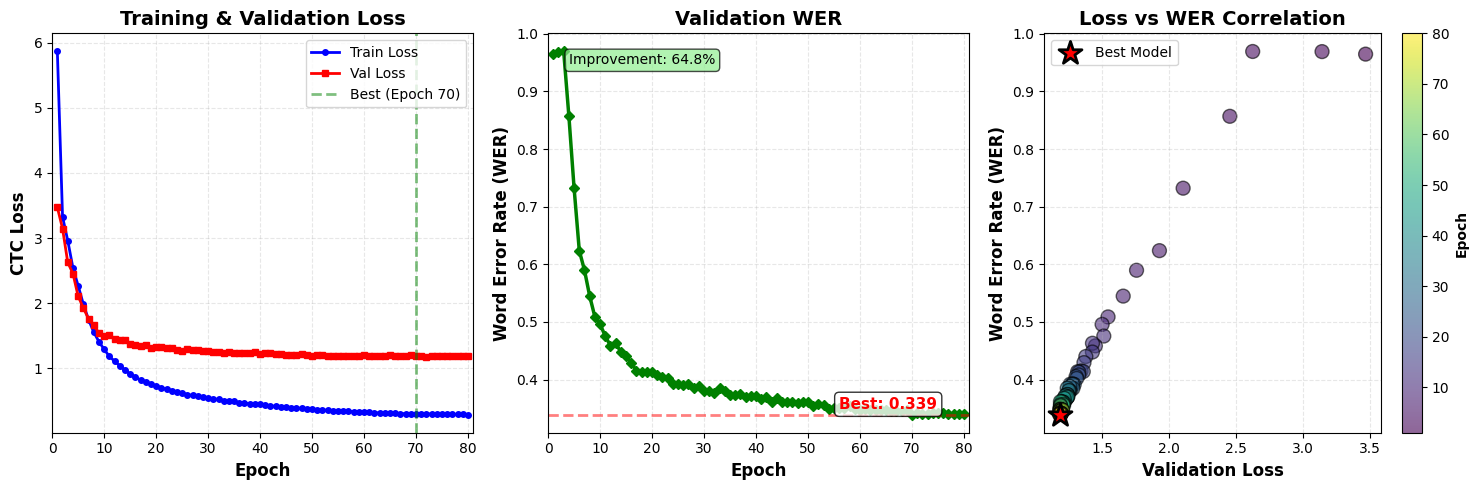


TRAINING SUMMARY
Total Epochs: 80
Best Epoch: 70

Initial WER: 0.965
Best WER: 0.339
Final WER: 0.340

Absolute Improvement: 0.625
Relative Improvement: 64.8%

Final Train Loss: 0.2899
Final Val Loss: 1.1869
Best Val Loss: 1.1798

✓ No significant overfitting detected


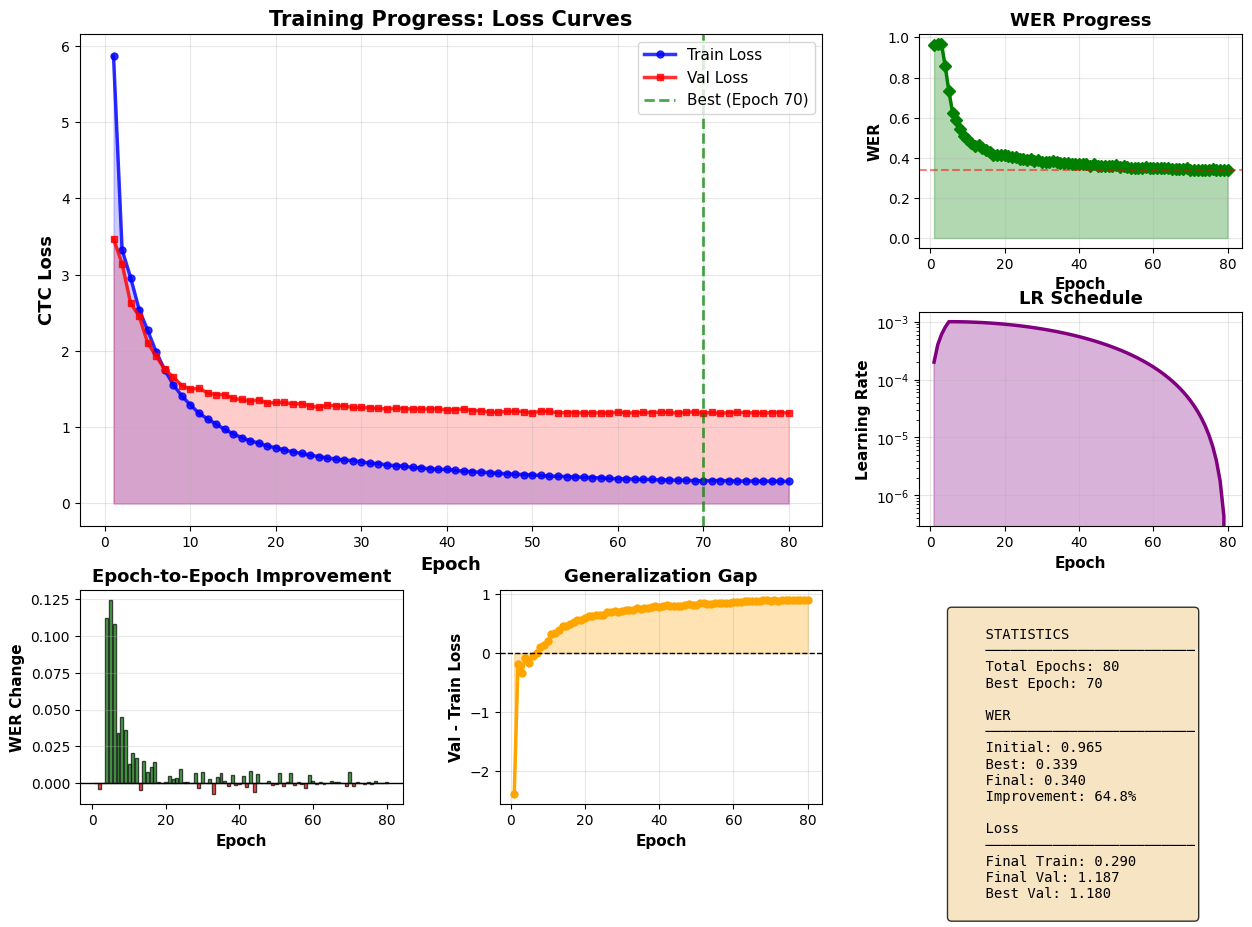


✓ Visualizations saved:
  - training_visualization.png
  - detailed_training_analysis.png


In [101]:
# =============================================================================
# TRAINING VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_training_metrics(train_losses, val_losses, val_wers, figsize=(15, 5)):
    """
    Visualize training progress

    Args:
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
        val_wers: List of validation WERs per epoch
    """
    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # ============ Plot 1: Loss Curves ============
    ax1 = axes[0]
    ax1.plot(epochs, train_losses, 'b-', linewidth=2, marker='o', markersize=4, label='Train Loss')
    ax1.plot(epochs, val_losses, 'r-', linewidth=2, marker='s', markersize=4, label='Val Loss')
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('CTC Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10, loc='upper right')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xlim(0, len(epochs) + 1)

    # Mark best epoch
    best_epoch = np.argmin(val_wers) + 1
    ax1.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, linewidth=2, label=f'Best (Epoch {best_epoch})')
    ax1.legend(fontsize=10, loc='upper right')

    # ============ Plot 2: WER Progression ============
    ax2 = axes[1]
    ax2.plot(epochs, val_wers, 'g-', linewidth=2.5, marker='D', markersize=5)
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
    ax2.set_title('Validation WER', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xlim(0, len(epochs) + 1)

    # Mark best WER
    best_wer = min(val_wers)
    ax2.axhline(y=best_wer, color='r', linestyle='--', alpha=0.5, linewidth=2)
    ax2.text(len(epochs) * 0.7, best_wer + 0.01, f'Best: {best_wer:.3f}',
             fontsize=11, color='r', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add improvement annotations
    initial_wer = val_wers[0]
    improvement = ((initial_wer - best_wer) / initial_wer) * 100
    ax2.text(0.05, 0.95, f'Improvement: {improvement:.1f}%',
             transform=ax2.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

    # ============ Plot 3: Loss vs WER (Correlation) ============
    ax3 = axes[2]
    scatter = ax3.scatter(val_losses, val_wers, c=epochs, cmap='viridis',
                         s=100, alpha=0.6, edgecolors='black', linewidth=1)
    ax3.set_xlabel('Validation Loss', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Word Error Rate (WER)', fontsize=12, fontweight='bold')
    ax3.set_title('Loss vs WER Correlation', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle='--')

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Epoch', fontsize=10, fontweight='bold')

    # Mark best point
    best_idx = np.argmin(val_wers)
    ax3.scatter(val_losses[best_idx], val_wers[best_idx],
               color='red', s=300, marker='*', edgecolors='black', linewidth=2,
               label='Best Model', zorder=5)
    ax3.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('training_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ============ Print Summary Statistics ============
    print("\n" + "="*60)
    print("TRAINING SUMMARY")
    print("="*60)
    print(f"Total Epochs: {len(train_losses)}")
    print(f"Best Epoch: {best_epoch}")
    print(f"\nInitial WER: {val_wers[0]:.3f}")
    print(f"Best WER: {best_wer:.3f}")
    print(f"Final WER: {val_wers[-1]:.3f}")
    print(f"\nAbsolute Improvement: {val_wers[0] - best_wer:.3f}")
    print(f"Relative Improvement: {improvement:.1f}%")
    print(f"\nFinal Train Loss: {train_losses[-1]:.4f}")
    print(f"Final Val Loss: {val_losses[-1]:.4f}")
    print(f"Best Val Loss: {min(val_losses):.4f}")

    # Overfitting check
    if val_losses[-1] > min(val_losses) * 1.1:
        print(f"\n⚠ Warning: Possible overfitting detected")
        print(f"   Val loss increased from {min(val_losses):.4f} to {val_losses[-1]:.4f}")
    else:
        print(f"\n✓ No significant overfitting detected")


def plot_detailed_analysis(train_losses, val_losses, val_wers, figsize=(15, 10)):
    """
    More detailed visualization with additional metrics
    """
    epochs = range(1, len(train_losses) + 1)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # ============ 1. Loss Curves (Large) ============
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    ax1.plot(epochs, train_losses, 'b-', linewidth=2.5, marker='o', markersize=5, label='Train Loss', alpha=0.8)
    ax1.plot(epochs, val_losses, 'r-', linewidth=2.5, marker='s', markersize=5, label='Val Loss', alpha=0.8)
    ax1.fill_between(epochs, train_losses, alpha=0.2, color='blue')
    ax1.fill_between(epochs, val_losses, alpha=0.2, color='red')
    ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax1.set_ylabel('CTC Loss', fontsize=13, fontweight='bold')
    ax1.set_title('Training Progress: Loss Curves', fontsize=15, fontweight='bold')
    ax1.legend(fontsize=11, loc='upper right')
    ax1.grid(True, alpha=0.3)

    best_epoch = np.argmin(val_wers) + 1
    ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best (Epoch {best_epoch})')
    ax1.legend(fontsize=11, loc='upper right')

    # ============ 2. WER Over Time ============
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(epochs, val_wers, 'g-', linewidth=2.5, marker='D', markersize=6)
    ax2.fill_between(epochs, val_wers, alpha=0.3, color='green')
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('WER', fontsize=11, fontweight='bold')
    ax2.set_title('WER Progress', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=min(val_wers), color='r', linestyle='--', alpha=0.5)

    # ============ 3. Learning Rate (if available) ============
    ax3 = fig.add_subplot(gs[1, 2])
    # Simulate LR schedule (warmup + cosine)
    warmup = 5
    total = len(epochs)
    lrs = []
    for e in range(1, total + 1):
        if e <= warmup:
            lr = 1e-3 * (e / warmup)
        else:
            progress = (e - warmup) / (total - warmup)
            lr = 1e-3 * 0.5 * (1 + np.cos(np.pi * progress))
        lrs.append(lr)

    ax3.plot(epochs, lrs, 'purple', linewidth=2.5)
    ax3.fill_between(epochs, lrs, alpha=0.3, color='purple')
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
    ax3.set_title('LR Schedule', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.set_yscale('log')

    # ============ 4. Improvement Rate ============
    ax4 = fig.add_subplot(gs[2, 0])
    wer_improvements = [0] + [val_wers[i-1] - val_wers[i] for i in range(1, len(val_wers))]
    colors = ['green' if x > 0 else 'red' for x in wer_improvements]
    ax4.bar(epochs, wer_improvements, color=colors, alpha=0.7, edgecolor='black')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax4.set_ylabel('WER Change', fontsize=11, fontweight='bold')
    ax4.set_title('Epoch-to-Epoch Improvement', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')

    # ============ 5. Train/Val Gap ============
    ax5 = fig.add_subplot(gs[2, 1])
    gap = np.array(val_losses) - np.array(train_losses)
    ax5.plot(epochs, gap, 'orange', linewidth=2.5, marker='o', markersize=5)
    ax5.fill_between(epochs, 0, gap, alpha=0.3, color='orange')
    ax5.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Val - Train Loss', fontsize=11, fontweight='bold')
    ax5.set_title('Generalization Gap', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3)

    # ============ 6. Statistics Table ============
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.axis('off')

    stats_text = f"""
    STATISTICS
    {'─'*25}
    Total Epochs: {len(train_losses)}
    Best Epoch: {best_epoch}

    WER
    {'─'*25}
    Initial: {val_wers[0]:.3f}
    Best: {min(val_wers):.3f}
    Final: {val_wers[-1]:.3f}
    Improvement: {((val_wers[0]-min(val_wers))/val_wers[0]*100):.1f}%

    Loss
    {'─'*25}
    Final Train: {train_losses[-1]:.3f}
    Final Val: {val_losses[-1]:.3f}
    Best Val: {min(val_losses):.3f}
    """

    ax6.text(0.1, 0.9, stats_text, transform=ax6.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.savefig('detailed_training_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================================
# USAGE
# =============================================================================

# Basic visualization
plot_training_metrics(train_losses, val_losses, val_wers)

# Detailed visualization
plot_detailed_analysis(train_losses, val_losses, val_wers)

print("\n✓ Visualizations saved:")
print("  - training_visualization.png")
print("  - detailed_training_analysis.png")